# Snakes and Ladders - Case Physa

---

## Respostas das perguntas

| # | Pergunta | Resposta |
|---|---|---|
| **1** | Probabilidade de o primeiro jogador vencer | **52,9% ± 1,0 p.p.** |
| **2** | Cobras por jogo (ambos os jogadores) | **3,11 ± 0,05** |
| **3** | Lançamentos por jogo com escadas a 50% | **22,46 ± 0,18** (+18,6% vs. base) |
| **4** | Casa inicial do Jogador 2 para equilibrar | **Casa 7** → P(J1) = 49,7% ± 0,3 p.p. |
| **5** | P(J1) com imunidade à primeira cobra do J2 | **38,2% ± 1,0 p.p.** |

---

## Estrutura do projeto

| Arquivo | Papel |
|---|---|
| `snakes_and_ladders.py` | Motor de simulação (apenas biblioteca padrão) |
| `analysis.py` | Agregação, intervalos de confiança e as cinco respostas |
| `analysis.ipynb` | Este notebook: gráficos e narrativa |



## 1. Configuração

![Tabuleiro do enunciado](board.jpg)

In [26]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd

import analysis as A
from snakes_and_ladders import Board, GameRules, GameEngine, ExperimentRunner, SEEDS

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.figsize": (10, 5.5),
    "figure.dpi": 120,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

BLUE, ORANGE, GREY, GREEN = "#4C72B0", "#DD8452", "#B0B0B0", "#55A868"
PCT = mticker.FuncFormatter(lambda v, _: f"{v:.1%}")

board = Board.create_physa_test_board()


### Metodologia

Para cada resposta foram simulados **10.000 jogos**, conforme o enunciado, contendo **intervalo de confiança de 95%**. Para a pergunta 4, foi feito um refinamento simulando **100.000 jogos**.

Todas as execuções usam sementes fixas, de modo que os números abaixo são reproduzíveis.

---
## Pergunta 1 —  Num jogo de duas pessoas, qual é a probabilidade do jogador que começa o jogo vencer?


In [27]:
a1 = A.q1(board)
a1_check = A.q1(board, A.N_CHECK)

print(f"P(Jogador 1 vence) = {a1['p1'].as_pct()}   [10.000 jogos]")
print(f"\nImplica P(empate em número de turnos) = {a1['tie_prob']:.1%}")

P(Jogador 1 vence) = 52.9% +- 1.0% p.p.   [10.000 jogos]

Implica P(empate em número de turnos) = 5.7%


**Análise:** Os jogadores não interagem, então a partida é apenas duas corridas independentes em paralelo. Seja `T` o número de lançamentos que um jogador precisa para completar o percurso sozinho: o Jogador 1 vence sempre que `T₁ ≤ T₂`, porque em caso de empate ele joga primeiro e chega antes.

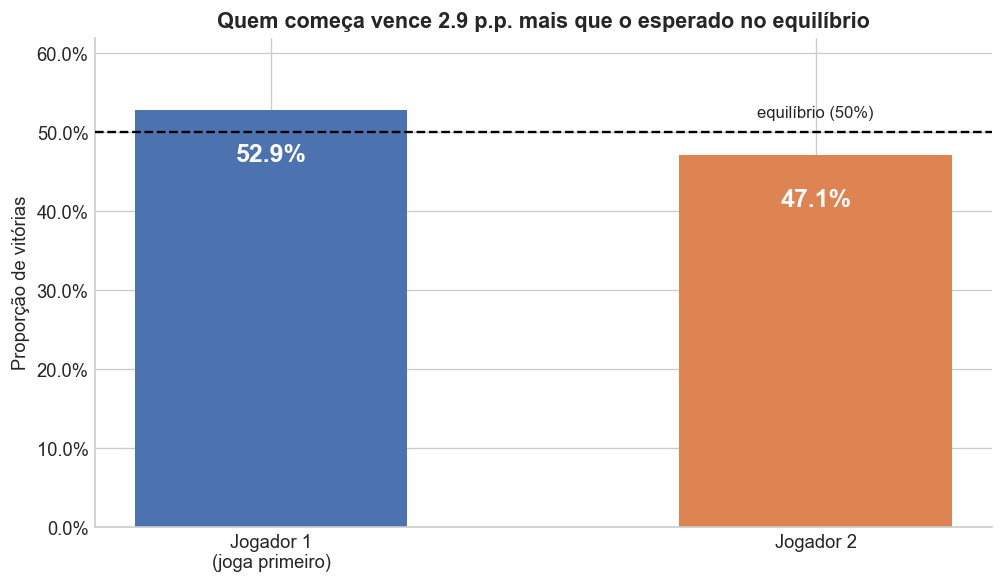

In [28]:
df1 = ExperimentRunner.to_dataframe(a1["results"])
share = df1.groupby("winner_index").size() / len(df1)

fig, ax = plt.subplots(figsize=(8.5, 5))
bars = ax.bar(["Jogador 1\n(joga primeiro)", "Jogador 2"], share.values,
              color=[BLUE, ORANGE], width=0.5)
ax.axhline(0.5, color="black", linestyle="--", linewidth=1.4, zorder=4)
ax.text(1.0, 0.515, "equilíbrio (50%)", fontsize=10, va="bottom", ha="center")

for bar, v in zip(bars, share.values):
    ax.text(bar.get_x() + bar.get_width() / 2, v - 0.065, f"{v:.1%}",
            ha="center", color="white", fontsize=15, fontweight="bold")

ax.set_ylim(0, 0.62)
ax.yaxis.set_major_formatter(PCT)
ax.set_ylabel("Proporção de vitórias")
ax.set_title(f"Quem começa vence {100 * (share[0] - 0.5):.1f} p.p. mais que o esperado no equilíbrio")
plt.tight_layout()
plt.show()

> **Resposta 1 — O Jogador 1 vence 52,9% das partidas (± 1,0 p.p.).**
>
> A vantagem de ~2,9 pontos percentuais vem inteiramente da ordem de jogada: em cerca de 5,7% das partidas os dois jogadores precisariam do mesmo número de turnos, e nessas quem começa leva todas.

---
## Pergunta 2 — Em média, em quantas cobras os jogadores caem a cada jogo?

In [29]:
a2 = A.q2(board)

print(f"Cobras por jogo (ambos os jogadores) = {a2['total']}")
print(f"  Jogador 1: {a2['p1']}")
print(f"  Jogador 2: {a2['p2']}")
print(f"\nReferência — corrida solo completa: {a2['solo']}")
print(f"Duas corridas completas dariam:     {2 * a2['solo'].value:.2f}")

Cobras por jogo (ambos os jogadores) = 3.11 +- 0.05
  Jogador 1: 1.60 +- 0.03
  Jogador 2: 1.51 +- 0.03

Referência — corrida solo completa: 2.16 +- 0.04
Duas corridas completas dariam:     4.32


**Análise:** A soma dos dois jogadores (3,11) é bem menor que duas corridas completas (4,32). O motivo: a partida termina no lançamento vencedor, então **o perdedor nunca completa o percurso** — sua corrida é interrompida no meio e ele enfrenta menos cobras do que enfrentaria sozinho.

Isso também explica por quê **o Jogador 1 cai em mais cobras que o Jogador 2**. Ele vence com mais frequência, completa o percurso mais vezes e, portanto, joga mais turnos. A diferença se mantém com 100.000 simulações, com intervalos de confiança que não se sobrepõem.

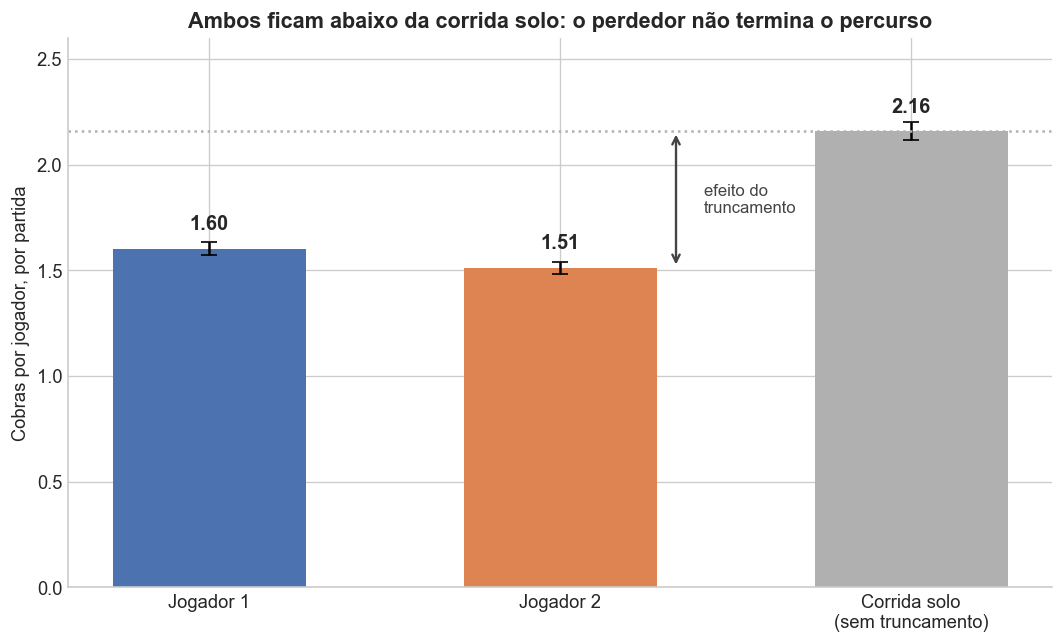

In [30]:
labels = ["Jogador 1", "Jogador 2", "Corrida solo\n(sem truncamento)"]
values = [a2["p1"].value, a2["p2"].value, a2["solo"].value]
errors = [a2["p1"].margin, a2["p2"].margin, a2["solo"].margin]

fig, ax = plt.subplots(figsize=(9, 5.5))
bars = ax.bar(labels, values, yerr=errors, capsize=5,
              color=[BLUE, ORANGE, GREY], width=0.55)
ax.axhline(a2["solo"].value, color=GREY, linestyle=":", linewidth=1.5)

for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.09, f"{v:.2f}",
            ha="center", fontsize=12, fontweight="bold")

ax.set_ylabel("Cobras por jogador, por partida")
ax.set_ylim(0, 2.6)
ax.set_title("Ambos ficam abaixo da corrida solo: o perdedor não termina o percurso")
ax.annotate("", xy=(1.33, a2["p2"].value), xytext=(1.33, a2["solo"].value),
            arrowprops=dict(arrowstyle="<->", color="#444444", lw=1.4))
ax.text(1.41, (a2["p2"].value + a2["solo"].value) / 2,
        "efeito do\ntruncamento", fontsize=10, va="center", color="#444444")
plt.tight_layout()
plt.show()

> **Resposta 2 — Os jogadores caem em 3,11 cobras por partida somando os dois (± 0,05).**
>
> Individualmente: **1,60** para o Jogador 1 e **1,51** para o Jogador 2. Numa corrida solo completa a média seria 2,17, e a diferença mede exatamente o efeito do truncamento do perdedor.

---
## Pergunta 3 — Se cada vez que um jogador cair em uma escada houver apenas 50% de chance de ele poder subir, qual é o número médio de lançamentos de dados necessários para completar um jogo?


In [31]:
a3 = A.q3(board)

print(f"Lançamentos por jogo (ambos) com escadas funcionando 50% das vezes = {a3['total']}")
print(f"  Jogador 1: {a3['p1']}")
print(f"  Jogador 2: {a3['p2']}")
print(f"\nCenário base com escadas sempre funcionando: {a3['baseline']}")
print(f"Efeito: {a3['increase_pct']:+.1f}% mais longo")

Lançamentos por jogo (ambos) com escadas funcionando 50% das vezes = 22.46 +- 0.18
  Jogador 1: 11.50 +- 0.09
  Jogador 2: 10.97 +- 0.09

Cenário base com escadas sempre funcionando: 18.94 +- 0.16
Efeito: +18.6% mais longo


Análise: o Jogador 1 lança mais vezes que o Jogador 2. A diferença entre as médias é igual a `P(J1 vence)`.

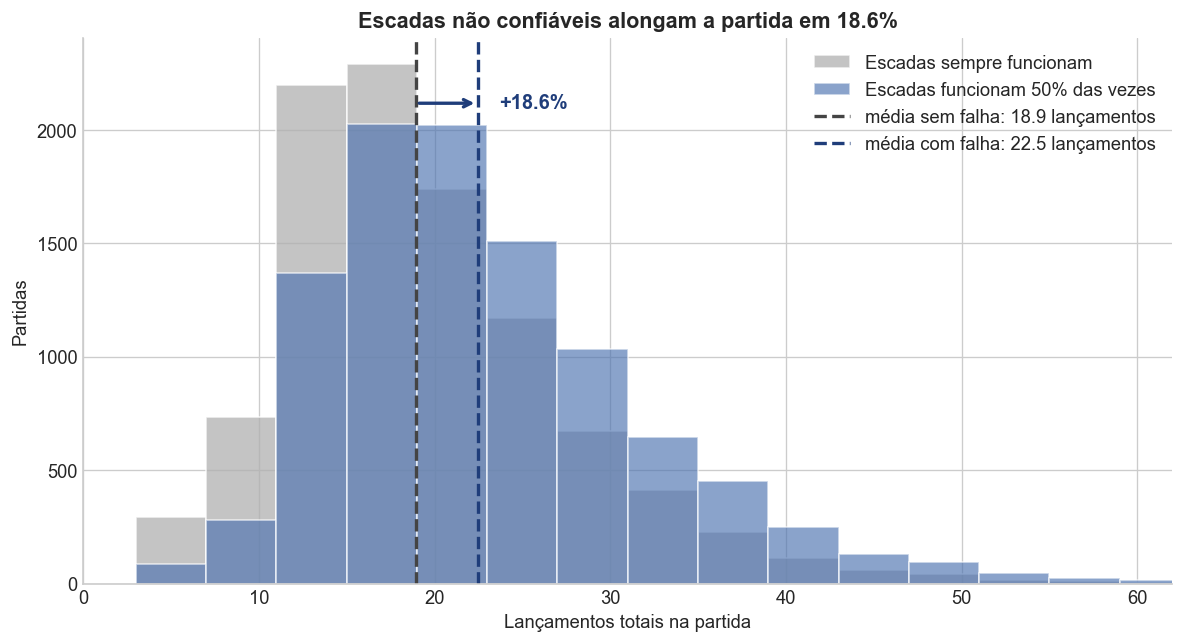

In [32]:
df3 = ExperimentRunner.to_dataframe(a3["results"])
df_base = ExperimentRunner.to_dataframe(
    A.run(board, GameRules(), SEEDS["q1_baseline"], A.N_GAMES)
)

fig, ax = plt.subplots(figsize=(10, 5.5))
bins = range(3, 71, 4)
ax.hist(df_base["total_rolls"], bins=bins, color=GREY, alpha=0.75,
        edgecolor="white", label="Escadas sempre funcionam")
ax.hist(df3["total_rolls"], bins=bins, color=BLUE, alpha=0.65,
        edgecolor="white", label="Escadas funcionam 50% das vezes")

ax.axvline(a3["baseline"].value, color="#444444", linestyle="--", linewidth=2,
           label=f"média sem falha: {a3['baseline'].value:.1f} lançamentos")
ax.axvline(a3["total"].value, color="#1F3D7A", linestyle="--", linewidth=2,
           label=f"média com falha: {a3['total'].value:.1f} lançamentos")

top = ax.get_ylim()[1]
ax.annotate("", xy=(a3["total"].value, top * 0.88),
            xytext=(a3["baseline"].value, top * 0.88),
            arrowprops=dict(arrowstyle="->", color="#1F3D7A", lw=2))
ax.text(a3["total"].value + 1.2, top * 0.88,
        f"+{a3['increase_pct']:.1f}%", ha="left", va="center", fontsize=12,
        fontweight="bold", color="#1F3D7A")

ax.set_xlim(0, 62)
ax.set_xlabel("Lançamentos totais na partida")
ax.set_ylabel("Partidas")
ax.set_title(f"Escadas não confiáveis alongam a partida em {a3['increase_pct']:.1f}%")
ax.legend()
plt.tight_layout()
plt.show()

> **Resposta 3 — São necessários 22,46 lançamentos por jogo (± 0,18), somando os dois jogadores.**
>
> Isso representa **+18,6%** em relação ao cenário base de 18,94 lançamentos. Por jogador, a média é de 11,50 e 10,97 lançamentos.

---
## Pergunta 4 — Você decide fazer experimentos para que os jogadores tenham aproximadamente chances iguais de vencerem o jogo. Você faz isso alterando a casa em que o Jogador 2 começa. Qual casa deveria ser a nova posição inicial do Jogador 2 para que as chances de vitória dos jogadores sejam aproximadamente iguais?

**Estratégia em duas etapas.** Com 10.000 jogos, o intervalo de confiança é de ±1,0 p.p. — maior que a diferença entre casas vizinhas. Por isso:

1. **Varredura:** testa as casas uma a uma a partir da casa 1 e para algumas casas depois que a probabilidade do jogador 1 começa a cair abaixo de 45%. A margem de paciência existe porque a curva **não é monótona**: cabeças de cobra (12, 14, 17) são casas ruins para começar e bases de escada valem mais do que o número sugere.
2. **Refino:** as três casas mais próximas de 50% são re-executadas com 100.000 jogos, reduzindo o intervalo para ±0,3 p.p.

In [33]:
a4 = A.q4(board)

print(f"Varredura ({A.N_GAMES:,} jogos por casa):")
for square, e in a4["sweep"]:
    print(f"  J2 começa na casa {square:>2}: P(J1 vence) = {e.as_pct()}")

print(f"\nRefino das finalistas ({a4['n_refine']:,} jogos):")
for square, e in sorted(a4["refined"]):
    mark = "  <-- melhor" if square == a4["best_square"] else ""
    print(f"  J2 começa na casa {square:>2}: P(J1 vence) = {e.as_pct()}{mark}")

print(f"\nResposta: casa {a4['best_square']} ({a4['best'].as_pct()})")

Varredura (10,000 jogos por casa):
  J2 começa na casa  1: P(J1 vence) = 52.1% +- 1.0% p.p.
  J2 começa na casa  2: P(J1 vence) = 52.1% +- 1.0% p.p.
  J2 começa na casa  3: P(J1 vence) = 54.2% +- 1.0% p.p.
  J2 começa na casa  4: P(J1 vence) = 52.8% +- 1.0% p.p.
  J2 começa na casa  5: P(J1 vence) = 51.7% +- 1.0% p.p.
  J2 começa na casa  6: P(J1 vence) = 51.8% +- 1.0% p.p.
  J2 começa na casa  7: P(J1 vence) = 48.6% +- 1.0% p.p.
  J2 começa na casa  8: P(J1 vence) = 48.8% +- 1.0% p.p.
  J2 começa na casa  9: P(J1 vence) = 43.5% +- 1.0% p.p.
  J2 começa na casa 10: P(J1 vence) = 42.9% +- 1.0% p.p.
  J2 começa na casa 11: P(J1 vence) = 43.7% +- 1.0% p.p.
  J2 começa na casa 12: P(J1 vence) = 38.8% +- 1.0% p.p.

Refino das finalistas (100,000 jogos):
  J2 começa na casa  5: P(J1 vence) = 51.9% +- 0.3% p.p.
  J2 começa na casa  7: P(J1 vence) = 49.7% +- 0.3% p.p.  <-- melhor
  J2 começa na casa  8: P(J1 vence) = 48.7% +- 0.3% p.p.

Resposta: casa 7 (49.7% +- 0.3% p.p.)


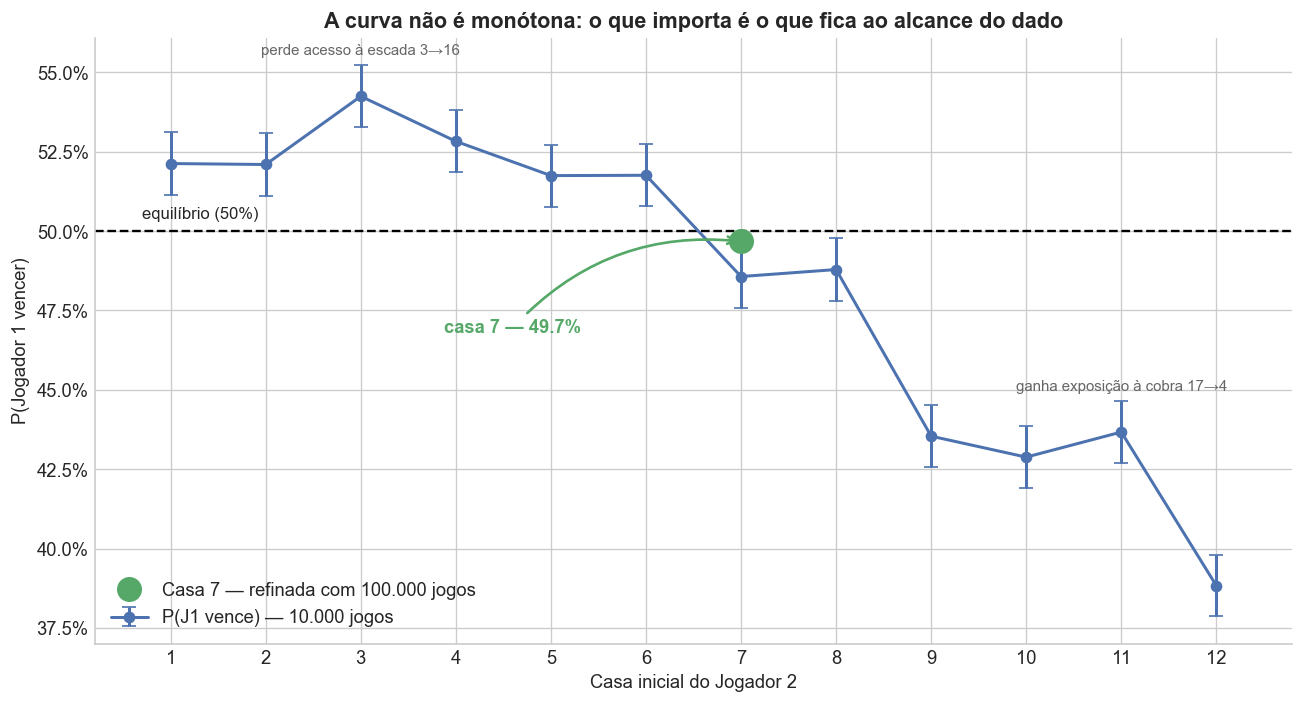

In [34]:
squares = [s for s, _ in a4["sweep"]]
probs = [e.value for _, e in a4["sweep"]]
margins = [e.margin for _, e in a4["sweep"]]
best = a4["best_square"]

fig, ax = plt.subplots(figsize=(11, 6))
ax.errorbar(squares, probs, yerr=margins, fmt="o-", color=BLUE,
            capsize=4, linewidth=1.8, markersize=6, label="P(J1 vence) — 10.000 jogos")
ax.axhline(0.5, color="black", linestyle="--", linewidth=1.4)
ax.text(squares[0] - 0.3, 0.503, "equilíbrio (50%)", fontsize=10, va="bottom", ha="left")

ax.plot([best], [a4["best"].value], "o", color=GREEN, markersize=14,
        zorder=5, label=f"Casa {best} — refinada com 100.000 jogos")
ax.annotate(f"casa {best} — {a4['best'].value:.1%}",
            xy=(best, a4["best"].value), xytext=(best - 2.4, 0.468),
            fontsize=11, fontweight="bold", color=GREEN, ha="center",
            arrowprops=dict(arrowstyle="->", color=GREEN, lw=1.6,
                            connectionstyle="arc3,rad=-0.25"))

for sq, lbl, ha in [(3, "perde acesso à escada 3→16", "center"),
                    (11, "ganha exposição à cobra 17→4", "center")]:
    if sq in squares:
        v = probs[squares.index(sq)]
        ax.annotate(lbl, xy=(sq, v), xytext=(sq, v + 0.013), fontsize=9,
                    color="#666666", ha=ha)

ax.set_xlabel("Casa inicial do Jogador 2")
ax.set_ylabel("P(Jogador 1 vencer)")
ax.set_xticks(squares)
ax.set_xlim(squares[0] - 0.8, squares[-1] + 0.8)
ax.yaxis.set_major_formatter(PCT)
ax.set_title("A curva não é monótona: o que importa é o que fica ao alcance do dado")
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()

**Análise:** A tendência geral é de queda — quanto mais à frente o Jogador 2 começa, menos o Jogador 1 vence. Mas há desvios importantes, o que muda é **o conjunto de casas ao alcance dos seis números seguintes**.

- **Casa 3 sobe P(J1) para 54,2%.** Começando ali, o Jogador 2 perde a possibilidade de cair na escada 3→16, a maior do tabuleiro. Da casa 2 ele ainda pode pisar nela.
- **Casa 11 (43,7%) é melhor para o J1 que a casa 10 (42,9%).** Da casa 11 o Jogador 2 alcança a casa 17, cabeça de cobra que devolve 13 casas — exposição que não existe partindo da casa 10.

É essa não-monotonicidade que justifica varrer as casas com margem de tolerância, em vez de parar no primeiro cruzamento de 50%.

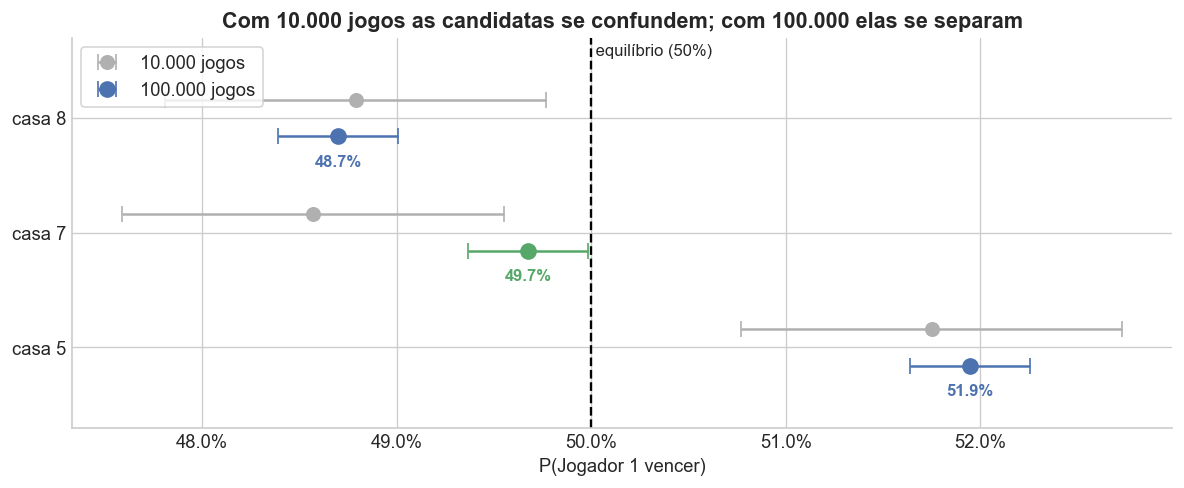

In [35]:
finalists = sorted(a4["refined"])
sweep_lookup = dict(a4["sweep"])
y = range(len(finalists))

fig, ax = plt.subplots(figsize=(10, 4.2))
for i, (square, e10) in enumerate([(sq, sweep_lookup[sq]) for sq, _ in finalists]):
    ax.errorbar(e10.value, i + 0.16, xerr=e10.margin, fmt="o", color=GREY,
                capsize=5, markersize=8,
                label="10.000 jogos" if i == 0 else None)
for i, (square, e) in enumerate(finalists):
    colour = GREEN if square == a4["best_square"] else BLUE
    ax.errorbar(e.value, i - 0.16, xerr=e.margin, fmt="o", color=colour,
                capsize=5, markersize=9,
                label="100.000 jogos" if i == 0 else None)
    ax.text(e.value, i - 0.42, f"{e.value:.1%}", ha="center", fontsize=10,
            fontweight="bold", color=colour)

ax.axvline(0.5, color="black", linestyle="--", linewidth=1.4)
ax.text(0.5, len(finalists) - 0.35, " equilíbrio (50%)", fontsize=10, va="top")
ax.set_yticks(list(y))
ax.set_yticklabels([f"casa {sq}" for sq, _ in finalists])
ax.set_ylim(-0.7, len(finalists) - 0.3)
ax.xaxis.set_major_formatter(PCT)
ax.set_xlabel("P(Jogador 1 vencer)")
ax.set_title("Com 10.000 jogos as candidatas se confundem; com 100.000 elas se separam")
ax.legend(loc="upper left", frameon=True)
plt.tight_layout()
plt.show()

Com 10.000 jogos (pontos cinza), os intervalos das casas 7 e 8 se sobrepõem quase por completo e a varredura chegou a apontar a casa 8. Com 100.000 jogos os intervalos se separam e a casa 7 emerge como a mais próxima do equilíbrio.

> **Resposta 4 — O Jogador 2 deveria começar na casa 7**, o que leva P(J1 vence) a **49,7% ± 0,3 p.p.**
>
> Nenhuma casa produz 50% exatos: a granularidade do tabuleiro impede o equilíbrio perfeito. A casa 7 deixa uma desvantagem residual de 0,3 p.p. para o Jogador 1 — dez vezes menor que a vantagem original de 2,9 p.p. A segunda melhor opção, casa 8, erra por 1,2 p.p.

---
## Pergunta 5 — Em uma tentativa diferente de alterar as chances do jogo, em vez de mudar a posição inicial do Jogador 2, você decide dar-lhe imunidade para a primeira cobra em que ele cair. Neste caso, qual é a probabilidade aproximada de que o Jogador 1 vença?

In [36]:
a5 = A.q5(board)

print(f"P(Jogador 1 vence) = {a5['p1'].as_pct()}")
print(f"Cenário base:        {a5['baseline'].as_pct()}")
print(f"\nEfeito: {a5['shift_pp']:+.1f} pontos percentuais")
print(f"Jogador 2 passa de {1 - a5['baseline'].value:.1%} para {1 - a5['p1'].value:.1%}")

P(Jogador 1 vence) = 38.2% +- 1.0% p.p.
Cenário base:        52.9% +- 1.0% p.p.

Efeito: -14.7 pontos percentuais
Jogador 2 passa de 47.1% para 61.8%


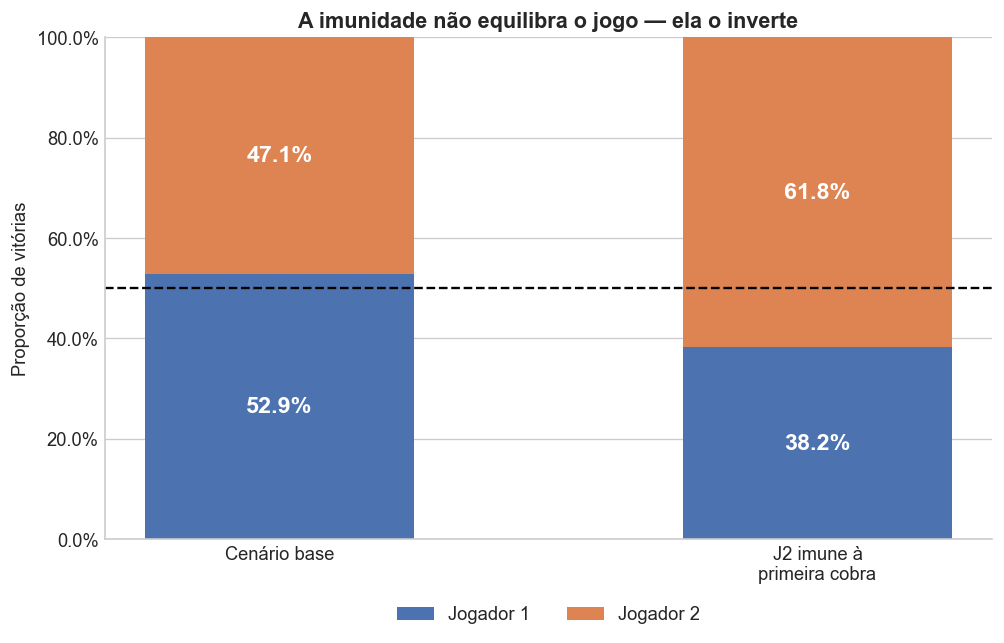

In [37]:
fig, ax = plt.subplots(figsize=(8.5, 5.5))

scenarios = ["Cenário base", "J2 imune à\nprimeira cobra"]
p1_vals = [a5["baseline"].value, a5["p1"].value]

ax.bar(scenarios, p1_vals, color=BLUE, width=0.5, label="Jogador 1")
ax.bar(scenarios, [1 - v for v in p1_vals], bottom=p1_vals, color=ORANGE,
       width=0.5, label="Jogador 2")
ax.axhline(0.5, color="black", linestyle="--", linewidth=1.4)

for i, v in enumerate(p1_vals):
    ax.text(i, v / 2, f"{v:.1%}", ha="center", va="center",
            color="white", fontsize=14, fontweight="bold")
    ax.text(i, v + (1 - v) / 2, f"{1 - v:.1%}", ha="center", va="center",
            color="white", fontsize=14, fontweight="bold")

ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(PCT)
ax.set_ylabel("Proporção de vitórias")
ax.set_title("A imunidade não equilibra o jogo — ela o inverte")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.10), ncol=2, frameon=False)
plt.tight_layout()
plt.show()

**Análise:** Uma cobra custa em média cerca de 10 casas, o equivalente a aproximadamente 3 lançamentos. Como um jogador faz apenas ~13 lançamentos na corrida completa, remover uma cobra elimina cerca de 22% do percurso efetivo.

> **Resposta 5 — O Jogador 1 vence apenas 38,2% das partidas (± 1,0 p.p.).**
>
> A imunidade é uma compensação excessiva: em vez de equilibrar, ela transfere a vantagem para o Jogador 2, que passa a vencer 61,8% das vezes.

---
## Considerações finais

**Sobre precisão.** As 10.000 simulações pedidas pelo enunciado entregam ±1,0 p.p. em probabilidades e são suficientes para quatro das cinco perguntas. A Pergunta 4 é a exceção: ela compara candidatas separadas por menos de 1 p.p., e nessa resolução o ranking seria ruído. O refino com 100.000 jogos resolveu isso, e vale registrar que a etapa de varredura sozinha teria apontado a casa 8 — a resposta errada.

**Sobre o método.** O erro amostral cai com a raiz do número de simulações: reduzir o intervalo pela metade exige quatro vezes mais jogos. Daí a estratégia de duas etapas, que gasta o orçamento computacional apenas onde a decisão depende dele.

**Limitações.** As respostas assumem dado justo de 6 lados, ausência de interação entre jogadores e o tabuleiro exatamente como lido da imagem do enunciado — a única entrada não verificável do modelo.